## Control Point Analysis + Trajectory Comparison

### Step 1: Load Average Trajectories

In [187]:
import numpy as np
import matplotlib.pyplot as plt

# Paths
immediate_path = r'C:\Users\Alishba\Downloads\prediction files\Transcriptions\data\models\recalls\trajectories\atlep1\avg_trajectory.npy'
delayed_path = r'C:\Users\Alishba\Downloads\prediction files\Transcriptions\data\models\recalls\trajectories\delayed\avg_trajectory.npy'

# Load
traj_immediate = np.load(immediate_path)
traj_delayed = np.load(delayed_path)

### Step 2: Visualize the 2 Trajectories (3D Projection)

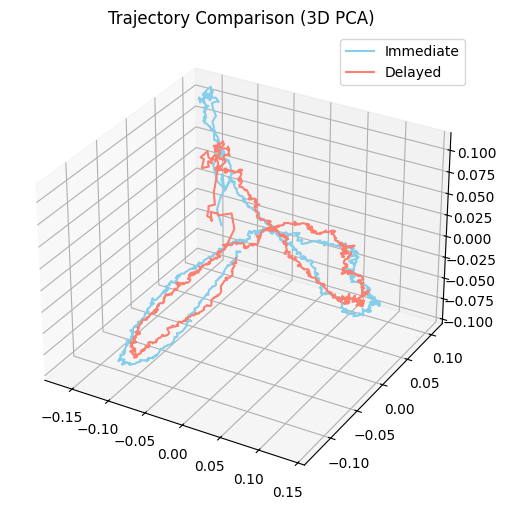

In [188]:
from sklearn.decomposition import PCA

def plot_trajectories(traj1, traj2, labels=('Immediate', 'Delayed')):
    pca = PCA(n_components=3)
    traj1_pca = pca.fit_transform(traj1)
    traj2_pca = pca.transform(traj2)

    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(*traj1_pca.T, label=labels[0], color='skyblue')
    ax.plot(*traj2_pca.T, label=labels[1], color='salmon')
    ax.set_title("Trajectory Comparison (3D PCA)")
    ax.legend()
    plt.show()

plot_trajectories(traj_immediate, traj_delayed)

### Step 3: Control Point Algorithm (Sliding 3-point Window)

In [189]:
from numpy.linalg import norm

def check_control_point(traj, threshold=0.01):
    control_points = []
    for i in range(1, len(traj)-1):
        p1, p2, p3 = traj[i-1], traj[i], traj[i+1]
        # Vector without middle point (shortcut)
        shortcut = p3 - p1
        shortcut_norm = norm(shortcut)
        # Actual path via p2
        path_via = norm(p2 - p1) + norm(p3 - p2)
        # Control point if difference is significant
        if abs(path_via - shortcut_norm) > threshold:
            control_points.append(i)
    return control_points

### Step 4: Apply & Compare Control Points

In [190]:
control_pts_imm = check_control_point(traj_immediate)
control_pts_del = check_control_point(traj_delayed)

print(f"Immediate Recall Control Points: {control_pts_imm}")
print(f"Delayed Recall Control Points: {control_pts_del}")

Immediate Recall Control Points: [1, 2, 13, 566, 626, 686, 695, 755, 808, 858, 928, 930, 936, 995, 997, 1075, 1121, 1209, 1420, 1428, 1429, 1430, 1431, 1433, 1434, 1437, 1443, 1444, 1446, 1448, 1449, 1451, 1453, 1454, 1456, 1458, 1459, 1460, 1461, 1462, 1463, 1464]
Delayed Recall Control Points: [1, 2, 3, 8, 94, 113, 115, 117, 238, 267, 482, 490, 682, 747, 842, 849, 880, 920, 921, 945, 1003, 1173, 1416, 1422, 1424, 1428, 1437, 1440, 1441, 1443, 1444, 1446, 1447, 1449, 1450, 1451, 1452, 1454, 1455, 1456, 1457, 1458, 1459, 1460, 1462, 1463, 1464]


### Step 5: Visualize with Control Points Highlighted

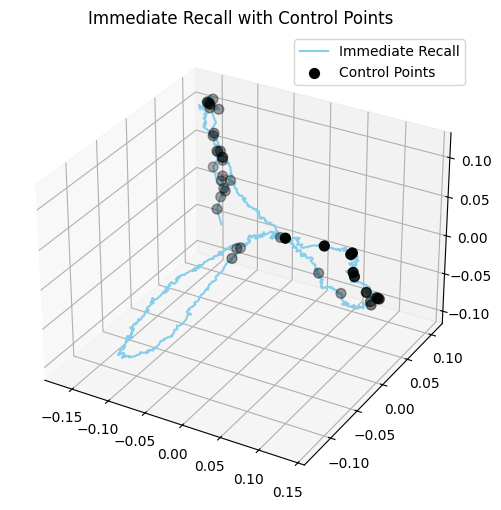

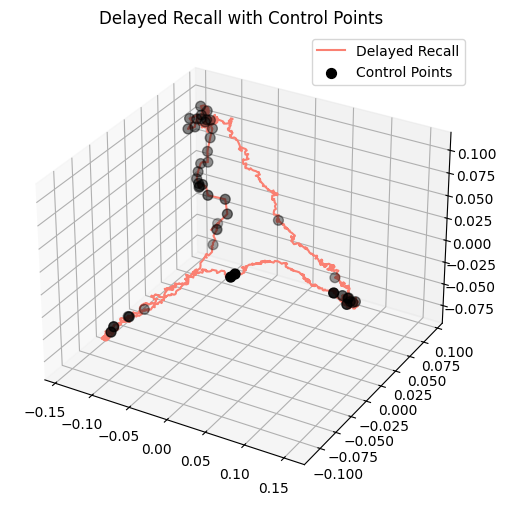

In [191]:
def plot_with_control_points(traj, control_pts, label='Trajectory', color='mediumseagreen'):
    pca = PCA(n_components=3)
    traj_pca = pca.fit_transform(traj)

    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(*traj_pca.T, label=label, color=color)
    ax.scatter(*traj_pca[control_pts].T, color='black', s=50, label='Control Points')
    ax.set_title(f"{label} with Control Points")
    ax.legend()
    plt.show()

plot_with_control_points(traj_immediate, control_pts_imm, 'Immediate Recall', 'skyblue')
plot_with_control_points(traj_delayed, control_pts_del, 'Delayed Recall', 'salmon')


### Control Point Function

In [192]:
def check_control_point(traj, threshold=0.01):
    control_points = []
    for i in range(1, len(traj)-1):
        p1, p2, p3 = traj[i-1], traj[i], traj[i+1]
        direct = np.linalg.norm(p1 - p3)
        via = np.linalg.norm(p1 - p2) + np.linalg.norm(p2 - p3)
        if abs(via - direct) > threshold:
            control_points.append(i)
    return control_points

### PCA Projection 

In [193]:
def reduce_pca(traj1, traj2, n_components=2):
    combined = np.vstack((traj1, traj2))
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(combined)
    return reduced[:len(traj1)], reduced[len(traj1):]

### Compare Trajectories and Control Points

In [194]:
def compare_control_point_paths(traj1, traj2, label1='Immediate', label2='Delayed'):
    cp1 = check_control_point(traj1, threshold=0.01)
    cp2 = check_control_point(traj2, threshold=0.01)

    traj1_2d, traj2_2d = reduce_pca(traj1, traj2)

    plt.figure(figsize=(10, 6))

    # Plot Immediate
    plt.plot(traj1_2d[:, 0], traj1_2d[:, 1], 'o-', color='skyblue', label=f'{label1} Trajectory')
    plt.scatter(traj1_2d[cp1, 0], traj1_2d[cp1, 1], color='blue', s=80, label=f'{label1} Control Points')

    # Plot Delayed
    plt.plot(traj2_2d[:, 0], traj2_2d[:, 1], 'o-', color='salmon', label=f'{label2} Trajectory')
    plt.scatter(traj2_2d[cp2, 0], traj2_2d[cp2, 1], color='red', s=80, label=f'{label2} Control Points')

    plt.title("Control Point Comparison in PCA Space")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return cp1, cp2

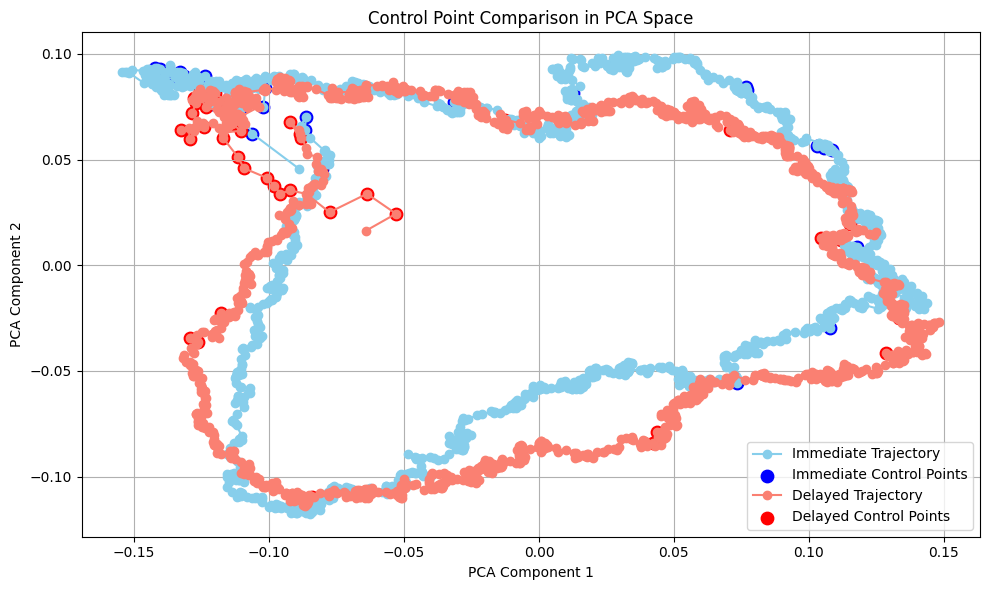

In [195]:
cp_imm, cp_del = compare_control_point_paths(traj_immediate, traj_delayed)

### Just Control Points

In [196]:
def plot_control_points_only(traj1, traj2, label1='Immediate Recall', label2='Delayed Recall', threshold=0.01):
    # Identify control points
    cp1 = check_control_point(traj1, threshold)
    cp2 = check_control_point(traj2, threshold)

    # Reduce both trajectories to 2D
    traj1_2d, traj2_2d = reduce_pca(traj1, traj2)

    # Extract just the control point coordinates
    cp1_coords = traj1_2d[cp1]
    cp2_coords = traj2_2d[cp2]

    # Begin Plot
    plt.figure(figsize=(8, 6))

    # Scatter control points
    plt.scatter(cp1_coords[:, 0], cp1_coords[:, 1], color='blue', label=f'{label1} Control Points', s=80)
    plt.scatter(cp2_coords[:, 0], cp2_coords[:, 1], color='red', label=f'{label2} Control Points', s=80)

    # Connect control points with lines
    plt.plot(cp1_coords[:, 0], cp1_coords[:, 1], color='blue', linestyle='-', alpha=0.6)
    plt.plot(cp2_coords[:, 0], cp2_coords[:, 1], color='red', linestyle='-', alpha=0.6)

    plt.title("Control Point Trajectories (Immediate vs Delayed Recall)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return cp1, cp2

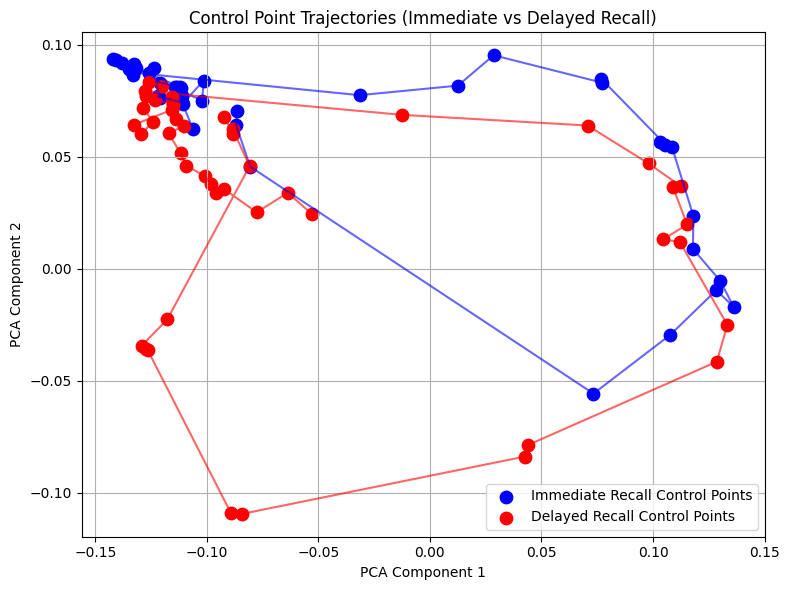

In [197]:
cp_imm, cp_del = plot_control_points_only(traj_immediate, traj_delayed)


### Euclidean Distance Measurements 

In [198]:
import numpy as np
from scipy.signal import resample
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt

def resample_trajectories(traj1, traj2, n_points=100):
    traj1_resampled = resample(traj1, n_points)
    traj2_resampled = resample(traj2, n_points)
    return traj1_resampled, traj2_resampled

def compute_pointwise_distances(traj1, traj2, method='euclidean'):
    distances = []
    for p1, p2 in zip(traj1, traj2):
        if method == 'euclidean':
            dist = euclidean(p1, p2)
        elif method == 'squared':
            dist = np.sum((p1 - p2) ** 2)
        else:
            raise ValueError("Unknown method. Use 'euclidean' or 'squared'.")
        distances.append(dist)
    return np.array(distances)

def plot_distance_along_trajectory(distances, label='Immediate vs Delayed'):
    plt.figure(figsize=(10, 4))
    plt.plot(distances, color='purple')
    plt.title(f'Pointwise Distance Between Trajectories ({label})')
    plt.xlabel('Trajectory Step')
    plt.ylabel('Distance')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

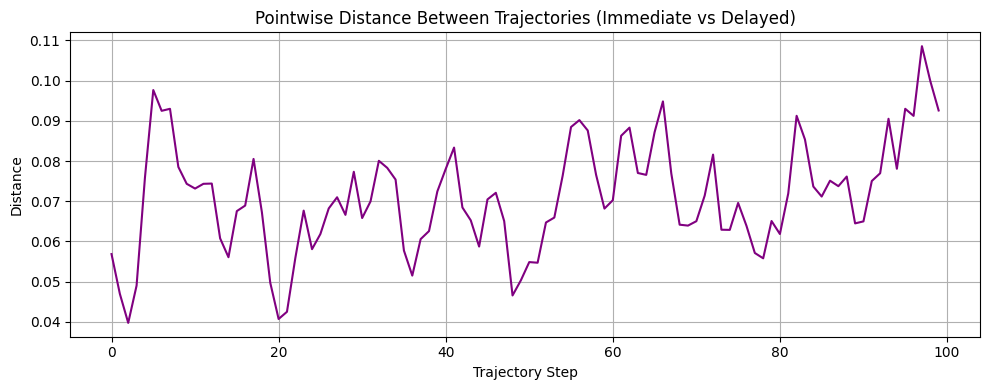

In [199]:
# Step 1: Resample both to same length
traj1_resampled, traj2_resampled = resample_trajectories(traj_immediate, traj_delayed, n_points=100)

# Step 2: Compute point-by-point distance
distances = compute_pointwise_distances(traj1_resampled, traj2_resampled, method='euclidean')

# Step 3: Plot distance pattern
plot_distance_along_trajectory(distances, label='Immediate vs Delayed')

In [200]:
print(f"Mean Distance: {distances.mean():.4f}")
print(f"Max Distance: {distances.max():.4f}")

Mean Distance: 0.0710
Max Distance: 0.1086


### Heatmap to Visualize the Distance Difference

In [201]:
import numpy as np
from scipy.signal import resample
from scipy.spatial.distance import euclidean
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Resample to same length
def resample_trajectories(traj1, traj2, n_points=100):
    traj1_resampled = resample(traj1, n_points)
    traj2_resampled = resample(traj2, n_points)
    return traj1_resampled, traj2_resampled

# Step 2: Compute pointwise Euclidean distance
def compute_distances(traj1, traj2):
    return np.array([euclidean(p1, p2) for p1, p2 in zip(traj1, traj2)])

# Step 3: Reduce to 2D for plotting
def reduce_to_2d(traj1, traj2):
    pca = PCA(n_components=2)
    combined = np.vstack([traj1, traj2])
    reduced = pca.fit_transform(combined)
    return reduced[:len(traj1)], reduced[len(traj1):]

# Step 4: Plot with heatmap
def plot_trajectory_with_heatmap(traj1_2d, traj2_2d, distances):
    norm_distances = (distances - distances.min()) / (distances.max() - distances.min())

    plt.figure(figsize=(10, 6))
    
    # Plot Immediate with heatmap
    for i in range(len(traj1_2d)-1):
        plt.plot([traj1_2d[i, 0], traj1_2d[i+1, 0]],
                 [traj1_2d[i, 1], traj1_2d[i+1, 1]],
                 color=plt.cm.viridis(1 - norm_distances[i]), linewidth=2)
    
    # Plot Delayed outline
    plt.plot(traj2_2d[:, 0], traj2_2d[:, 1], color='gray', alpha=0.4, label='Delayed Recall', linestyle='--')
    
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=distances.min(), vmax=distances.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=plt.gca(), label='Euclidean Distance (Immediate vs Delayed)')
    
    plt.title('Immediate Recall Trajectory (Heatmap) vs Delayed Recall')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

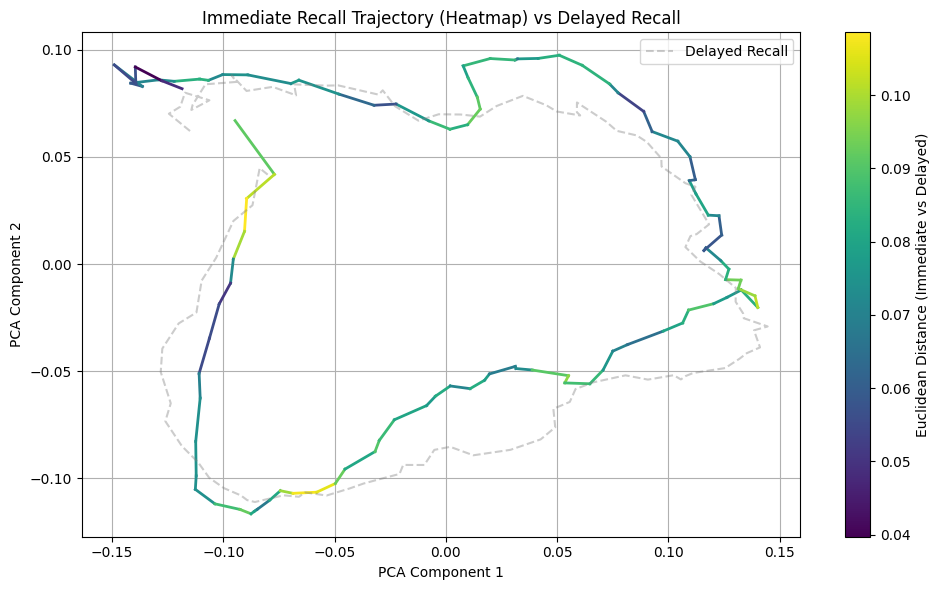

In [202]:
traj1_resampled, traj2_resampled = resample_trajectories(traj_immediate, traj_delayed, n_points=100)
distances = compute_distances(traj1_resampled, traj2_resampled)
traj1_2d, traj2_2d = reduce_to_2d(traj1_resampled, traj2_resampled)
plot_trajectory_with_heatmap(traj1_2d, traj2_2d, distances)

### Further Improvement (Multi-scale control point detection)

In [203]:
import numpy as np
from numpy.linalg import norm

def check_control_point_multiscale(traj, thresholds=[0.005, 0.01, 0.02], max_scale=5):
    n = len(traj)
    scores = np.zeros(n)

    for scale in range(1, max_scale + 1):
        for i in range(scale, n - scale):
            p1, p2, p3 = traj[i - scale], traj[i], traj[i + scale]
            direct = norm(p3 - p1)
            via = norm(p2 - p1) + norm(p3 - p2)
            delta = abs(via - direct)
            for threshold in thresholds:
                if delta > threshold:
                    scores[i] += 1  # Add point if it exceeds threshold at this scale

    # Normalize scores between 0 and 1
    norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

    # Select "strong" control points with high score
    control_points = [i for i, s in enumerate(norm_scores) if s > 0.5]

    return control_points, norm_scores

### Visualization Function (Multiscale Control Point Scores)

In [204]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_multiscale_control_points(traj, control_points, scores, title="Control Point Scores (Multiscale)"):
    pca = PCA(n_components=2)
    traj_2d = pca.fit_transform(traj)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot trajectory
    ax.plot(traj_2d[:, 0], traj_2d[:, 1], color='gray', alpha=0.5, label='Trajectory')

    # Plot control points with color-coded scores
    scatter = ax.scatter(traj_2d[control_points, 0],
                         traj_2d[control_points, 1],
                         c=scores[control_points],
                         cmap='plasma', s=80, label='Control Points')

    # Colorbar (linked to Axes)
    cbar = fig.colorbar(scatter, ax=ax, label='Control Point Score')

    ax.set_title(title)
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

### Running CPD on trajectory

In [205]:
control_points, scores = check_control_point_multiscale(
    traj_immediate,
    thresholds=[0.005, 0.01, 0.02],
    max_scale=5
)

### Visualizing Control Points

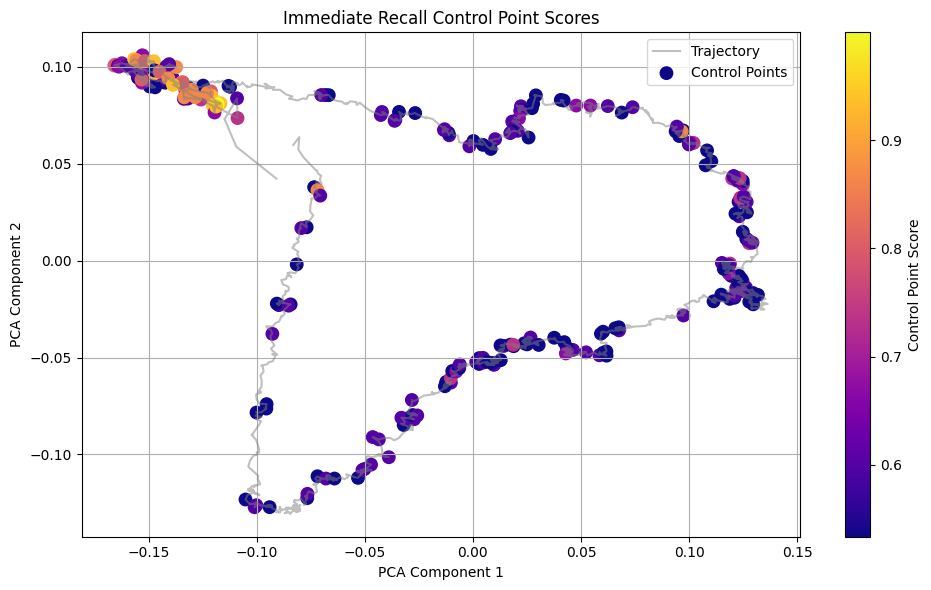

In [206]:
plot_multiscale_control_points(
    traj_immediate,
    control_points,
    scores,
    title="Immediate Recall Control Point Scores"
)